# HW13 – токенизация текста, инференс BERT и базовый fine-tuning для классификации

Датасет: `emotion`  
Модель для fine-tuning: `distilbert-base-uncased`  
Готовый инференс: pretrained emotion-модель  

In [32]:
# Шаг 1. Импорты библиотек

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    pipeline
)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from transformers.utils.notebook import NotebookProgressCallback

In [12]:
# Шаг 2. Фиксация seed и определение устройства

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"SEED: {SEED}")
print(f"DEVICE: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

SEED: 42
DEVICE: cuda
CUDA available: True
NVIDIA GeForce RTX 4060 Ti


In [13]:
# Шаг 3. Подготовка путей и папки artifacts

ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print("Artifacts directory:", os.path.abspath(ARTIFACTS_DIR))

Artifacts directory: c:\Users\Dilvi\Desktop\Mirea-aie-dpo\homeworks\HW13\artifacts


In [14]:
# Шаг 4. Загрузка датасета emotion

dataset = load_dataset("emotion")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [15]:
# Шаг 5. Sanity-check данных: размеры split-частей, классы, несколько примеров текстов и меток

print("Split sizes:")
for split_name in dataset.keys():
    print(split_name, len(dataset[split_name]))

label_feature = dataset["train"].features["label"]
label_names = label_feature.names

print("\nClass names:")
for i, name in enumerate(label_names):
    print(i, "-", name)

print("\nНесколько примеров из train:")
sample_df = pd.DataFrame(dataset["train"][:5])
sample_df["label_name"] = sample_df["label"].apply(lambda x: label_names[x])
sample_df

Split sizes:
train 16000
validation 2000
test 2000

Class names:
0 - sadness
1 - joy
2 - love
3 - anger
4 - fear
5 - surprise

Несколько примеров из train:


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## Краткое описание задачи

В датасете `emotion` нужно классифицировать короткие тексты по эмоциональным классам.  
В данной работе используется 6 классов: `sadness`, `joy`, `love`, `anger`, `fear`, `surprise`.  
Это задача многоклассовой классификации текста.

In [16]:
# Шаг 6. Выбор BERT-подобной модели и токенизатора для fine-tuning

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

print("Tokenizer loaded:", model_checkpoint)
print("Special tokens:")
print("CLS token:", tokenizer.cls_token)
print("SEP token:", tokenizer.sep_token)
print("PAD token:", tokenizer.pad_token)
print("UNK token:", tokenizer.unk_token)
print("MASK token:", tokenizer.mask_token)

Tokenizer loaded: distilbert-base-uncased
Special tokens:
CLS token: [CLS]
SEP token: [SEP]
PAD token: [PAD]
UNK token: [UNK]
MASK token: [MASK]


In [17]:
# Шаг 7. Базовый разбор токенизации для 3-5 текстов по требованиям homework.md

example_texts = [
    dataset["train"][0]["text"],
    dataset["train"][1]["text"],
    dataset["train"][2]["text"],
    "I am feeling absolutely wonderful today!",
    "I am scared and do not know what will happen next."
]

for i, text in enumerate(example_texts, 1):
    encoded = tokenizer(text, truncation=True, padding=False)
    tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])
    
    print("=" * 100)
    print(f"Example {i}")
    print("Text:", text)
    print("Tokens:", tokens)
    print("Input IDs:", encoded["input_ids"])
    print("Attention mask:", encoded["attention_mask"])

Example 1
Text: i didnt feel humiliated
Tokens: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]']
Input IDs: [101, 1045, 2134, 2102, 2514, 26608, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1]
Example 2
Text: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Tokens: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
Input IDs: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 1998, 2003, 8300, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Example 3
Text: im grabbing a minute to post i feel greedy wrong
Tokens: ['[CLS]', 'im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong', '[SEP]']
Input IDs: [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20

In [18]:
# Шаг 8. Показ примера padding и truncation по требованиям homework.md

texts_for_padding = [
    "I feel good.",
    "I feel very happy today because everything is going well.",
    "This is a longer sentence created specially to demonstrate how truncation works in transformer tokenization."
]

encoded_batch = tokenizer(
    texts_for_padding,
    padding=True,
    truncation=True,
    max_length=12,
    return_tensors="pt"
)

print("Input IDs shape:", encoded_batch["input_ids"].shape)
print("Attention mask shape:", encoded_batch["attention_mask"].shape)

for i, text in enumerate(texts_for_padding):
    print("=" * 100)
    print("Original text:", text)
    print("Decoded tokens:", tokenizer.convert_ids_to_tokens(encoded_batch["input_ids"][i].tolist()))
    print("Input IDs:", encoded_batch["input_ids"][i].tolist())
    print("Attention mask:", encoded_batch["attention_mask"][i].tolist())

Input IDs shape: torch.Size([3, 12])
Attention mask shape: torch.Size([3, 12])
Original text: I feel good.
Decoded tokens: ['[CLS]', 'i', 'feel', 'good', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Input IDs: [101, 1045, 2514, 2204, 1012, 102, 0, 0, 0, 0, 0, 0]
Attention mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]
Original text: I feel very happy today because everything is going well.
Decoded tokens: ['[CLS]', 'i', 'feel', 'very', 'happy', 'today', 'because', 'everything', 'is', 'going', 'well', '[SEP]']
Input IDs: [101, 1045, 2514, 2200, 3407, 2651, 2138, 2673, 2003, 2183, 2092, 102]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Original text: This is a longer sentence created specially to demonstrate how truncation works in transformer tokenization.
Decoded tokens: ['[CLS]', 'this', 'is', 'a', 'longer', 'sentence', 'created', 'specially', 'to', 'demonstrate', 'how', '[SEP]']
Input IDs: [101, 2023, 2003, 1037, 2936, 6251, 2580, 11974, 2000, 10580, 2129, 

In [19]:
# Шаг 9. Инференс готовой pretrained модели на нескольких текстах по требованиям homework.md

inference_model_name = "j-hartmann/emotion-english-distilroberta-base"

emotion_pipe = pipeline(
    "text-classification",
    model=inference_model_name,
    tokenizer=inference_model_name,
    device=0 if torch.cuda.is_available() else -1
)

inference_texts = [
    dataset["test"][0]["text"],
    dataset["test"][1]["text"],
    dataset["test"][2]["text"],
    "I am extremely happy and grateful for this day.",
    "I feel nervous and frightened about tomorrow."
]

results = emotion_pipe(inference_texts)

for text, result in zip(inference_texts, results):
    print("=" * 100)
    print("Text:", text)
    print("Predicted label:", result["label"])
    print("Score:", round(result["score"], 4))

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Text: im feeling rather rotten so im not very ambitious right now
Predicted label: sadness
Score: 0.9915
Text: im updating my blog because i feel shitty
Predicted label: sadness
Score: 0.9933
Text: i never make her separate from me because i don t ever want her to feel like i m ashamed with her
Predicted label: sadness
Score: 0.9825
Text: I am extremely happy and grateful for this day.
Predicted label: joy
Score: 0.9902
Text: I feel nervous and frightened about tomorrow.
Predicted label: fear
Score: 0.9948


## Комментарий к готовому инференсу

Готовая pretrained-модель уже умеет распознавать эмоции, поэтому на примерах она даёт разумные ответы без дополнительного обучения.  
Однако эта модель обучалась не строго под наш датасет `emotion`, поэтому её классы и распределение данных могут не совпадать с нашей постановкой полностью.  
Именно поэтому для корректной учебной постановки нужен отдельный fine-tuning на выбранном датасете.

In [20]:
# Шаг 10. Подготовка отображения классов для fine-tuning модели

id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print("id2label:", id2label)
print("label2id:", label2id)

id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
label2id: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


In [21]:
# Шаг 11. Подготовка токенизации датасета для fine-tuning

MAX_LENGTH = 128

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

In [22]:
# Шаг 12. Токенизация train / validation / test

tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenized_dataset

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [23]:
# Шаг 13. Подготовка формата датасета для Trainer

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})


In [24]:
# Шаг 14. Метрики accuracy и f1_macro

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    
    return {
        "accuracy": acc,
        "f1_macro": f1
    }

In [25]:
# Шаг 15. Загрузка BERT-подобной модели для sequence classification

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

model.to(device)

print("Model loaded:", model_checkpoint)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased


In [26]:
# Шаг 16. Настройка fine-tuning

training_args = TrainingArguments(
    output_dir="./hw13_outputs",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    seed=SEED,
    report_to="none"
)

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [34]:
# Шаг 17. Создание Trainer и выбор лучшего варианта по validation

from transformers.utils.notebook import NotebookProgressCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# Шаг 17.1. Удаляем проблемный notebook callback
trainer.remove_callback(NotebookProgressCallback)

print("Trainer created successfully.")
print("Callbacks:")
for cb in trainer.callback_handler.callbacks:
    print("-", cb.__class__.__name__)

Trainer created successfully.
Callbacks:
- DefaultFlowCallback


In [30]:
# Шаг 18. Запуск fine-tuning

train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.488737,0.195861,0.926000,0.898904
2,0.148734,0.160399,0.937500,0.909875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.3187353744506836, metrics={'train_runtime': 136.1943, 'train_samples_per_second': 234.958, 'train_steps_per_second': 14.685, 'total_flos': 389287358125632.0, 'train_loss': 0.3187353744506836, 'epoch': 2.0})

In [35]:
# Шаг 19. Проверка модели на validation после fine-tuning

val_metrics = trainer.evaluate(tokenized_dataset["validation"])
val_metrics

{'eval_loss': 0.16039861738681793,
 'eval_model_preparation_time': 0.001,
 'eval_accuracy': 0.9375,
 'eval_f1_macro': 0.9098748650347995,
 'eval_runtime': 2.9583,
 'eval_samples_per_second': 676.071,
 'eval_steps_per_second': 42.254,
 'epoch': 0}

In [36]:
# Шаг 20. Финальная оценка лучшего варианта на test

test_metrics = trainer.evaluate(tokenized_dataset["test"])
test_metrics

{'eval_loss': 0.18009591102600098,
 'eval_model_preparation_time': 0.001,
 'eval_accuracy': 0.929,
 'eval_f1_macro': 0.8866721725966858,
 'eval_runtime': 2.9293,
 'eval_samples_per_second': 682.75,
 'eval_steps_per_second': 42.672,
 'epoch': 0}

In [37]:
# Шаг 21. Получение предсказаний на test для матрицы ошибок и сохранения sample_predictions.csv

pred_output = trainer.predict(tokenized_dataset["test"])

test_logits = pred_output.predictions
test_labels = pred_output.label_ids
test_preds = np.argmax(test_logits, axis=1)

test_probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()
test_confidences = test_probs.max(axis=1)

print("Predictions shape:", test_logits.shape)
print("Labels shape:", test_labels.shape)

Predictions shape: (2000, 6)
Labels shape: (2000,)


In [38]:
# Шаг 22. Расчёт итоговых метрик вручную для наглядности

test_accuracy = accuracy_score(test_labels, test_preds)
test_f1_macro = f1_score(test_labels, test_preds, average="macro")

print("Final test_accuracy:", round(test_accuracy, 4))
print("Final test_f1_macro:", round(test_f1_macro, 4))

Final test_accuracy: 0.929
Final test_f1_macro: 0.8867


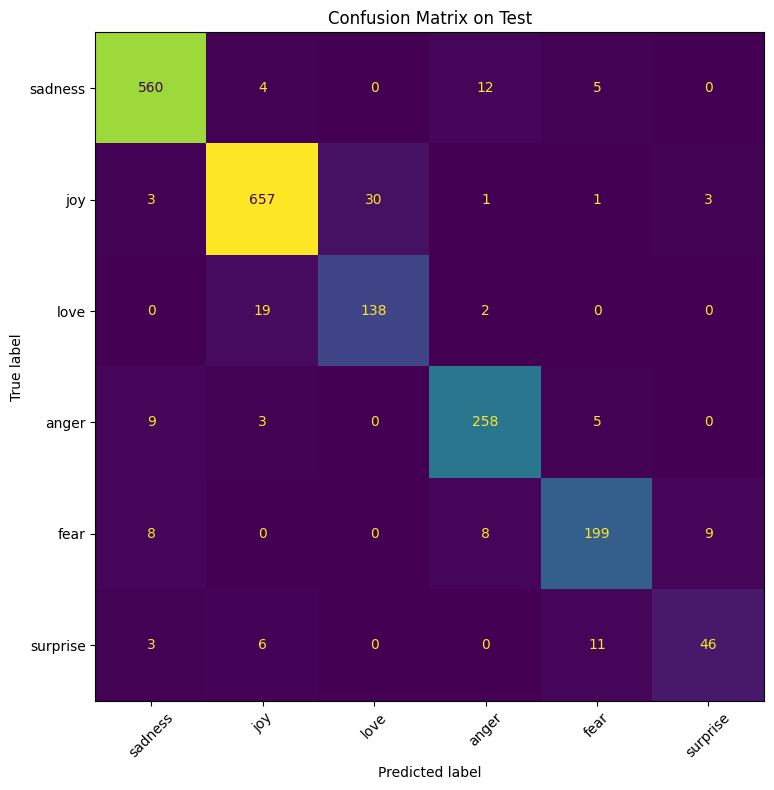

Saved: artifacts\confusion_matrix.png


In [39]:
# Шаг 23. Построение и сохранение confusion matrix в artifacts/confusion_matrix.png

cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix on Test")
plt.tight_layout()

confusion_matrix_path = os.path.join(ARTIFACTS_DIR, "confusion_matrix.png")
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", confusion_matrix_path)

In [40]:
# Шаг 24. Сохранение примеров предсказаний модели в artifacts/sample_predictions.csv

test_texts = dataset["test"]["text"]

pred_df = pd.DataFrame({
    "text": test_texts,
    "true_label": [label_names[x] for x in test_labels],
    "pred_label": [label_names[x] for x in test_preds],
    "confidence": test_confidences
})

sample_predictions_path = os.path.join(ARTIFACTS_DIR, "sample_predictions.csv")
pred_df.to_csv(sample_predictions_path, index=False, encoding="utf-8")

print("Saved:", sample_predictions_path)
pred_df.head(10)

Saved: artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.997477
1,im updating my blog because i feel shitty,sadness,sadness,0.997709
2,i never make her separate from me because i do...,sadness,sadness,0.997711
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.997528
4,i was feeling a little vain when i did this one,sadness,sadness,0.997722
5,i cant walk into a shop anywhere where i do no...,fear,fear,0.994512
6,i felt anger when at the end of a telephone call,anger,anger,0.993160
7,i explain why i clung to a relationship with a...,joy,joy,0.878484
8,i like to have the same breathless feeling as ...,joy,joy,0.997333
9,i jest i feel grumpy tired and pre menstrual w...,anger,anger,0.995629


In [41]:
# Шаг 25. Показ 10 примеров предсказаний модели

pred_df.sample(10, random_state=SEED)

,text,true_label,pred_label,confidence
1860,i feel so dirty but after spending a day at th...,sadness,sadness,0.997460
353,i could feel his breath on me and smell the sw...,joy,love,0.877196
1333,i just want to feel loved by you,love,love,0.981236
905,i have felt the need to write out my sometimes...,anger,anger,0.955036
1289,at a party i met a girl who drew me to her,anger,fear,0.643376
1273,i feel this strange sort of liberation,surprise,fear,0.670478
938,i remember feeling thrilled to use my nursing ...,joy,joy,0.997635
1731,i always feel sympathetic for those that do as...,love,love,0.984155
65,i feel a little stunned but can t imagine what...,surprise,surprise,0.968413
1323,i feel slytherin is my house slytherin is for ...,joy,joy,0.832559


In [42]:
# Шаг 26. Краткий анализ нескольких ошибок модели

errors_df = pred_df[pred_df["true_label"] != pred_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

print("Количество ошибок:", len(errors_df))
errors_df.head(10)

Количество ошибок: 142


,text,true_label,pred_label,confidence
1533,i actually was in a meeting last week where so...,anger,sadness,0.997381
816,whenever i put myself in others shoes and try ...,anger,joy,0.996873
1928,i feel inside cause life is like a game someti...,fear,sadness,0.993571
426,i feel unprotected a class post count link hre...,sadness,fear,0.992272
1146,i feel affirmed gracious sensuous and will hav...,love,joy,0.992031
1431,i felt a stronger wish to be free from self ch...,sadness,joy,0.990935
290,i just feel are ludicrous and wasting space or...,surprise,sadness,0.990180
660,i was playing a sport in an advanced pe class ...,anger,joy,0.989227
1188,i felt confused me sometimes that makes me fee...,sadness,fear,0.987680
1020,i know is that she s here and i m so thankful ...,sadness,joy,0.987406


## Краткий анализ ошибок

При анализе ошибок модели можно заметить, что большинство неверных предсказаний возникает на пограничных случаях, где эмоциональная окраска текста неочевидна или может интерпретироваться несколькими способами.

Чаще всего модель путает близкие по смыслу классы, например:
- sadness и fear
- joy и surprise

Это связано с тем, что такие эмоции могут выражаться похожими словами или контекстами.

Также ошибки чаще встречаются:
- на коротких текстах (мало информации),
- на неоднозначных фразах,
- на текстах без явных эмоциональных маркеров.

В целом модель хорошо справляется с ярко выраженными эмоциями, но испытывает сложности на более тонких и смешанных состояниях.